In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [42]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
!wget $data -O data_hw.csv

--2026-06-09 07:33:26--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘data_hw.csv’

data_hw.csv         100%[===================>]  78.98K  --.-KB/s    in 0.001s  

2026-06-09 07:33:27 (57.9 MB/s) - ‘data_hw.csv’ saved [80876/80876]



In [63]:
df = pd.read_csv('data_hw.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


Note: sometimes your answer doesn't match one of the options exactly. That's fine. Select the option that's closest to your solution. If it's exactly in between two options, select the higher value.

## Data preparation
Check if the missing values are presented in the features.
If there are missing values:
1. For caterogiral features, replace them with 'NA'
2. For numerical features, replace with with 0.0

Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1

In [64]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [65]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [68]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

## Question 1: ROC AUC feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables.

For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
Use the training dataset for that
If your AUC is < 0.5, invert this variable by putting "-" in front (e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC? b. number_of_courses_viewed

In [69]:
from sklearn.metrics import roc_auc_score

In [70]:
for col in numerical:
    print(col, roc_auc_score(y_train, df_train[col]))

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


## Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits) c. 0.72, actual 0.82 but not an option

In [71]:
from sklearn.feature_extraction import DictVectorizer

In [72]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.57539503, 0.47060769, 0.61901236, 0.6143892 , 0.61741031,
       0.67496748, 0.8465351 , 0.38205016, 0.55735358, 0.91246751,
       0.77549359, 0.66110422, 0.91574386, 0.38389183, 0.88197523,
       0.89511778, 0.65336369, 0.53077648, 0.73106703, 0.70418456,
       0.78080321, 0.51381844, 0.88869813, 0.72195815, 0.91633086,
       0.53483932, 0.50123084, 0.84175873, 0.48497478, 0.60635462,
       0.63002389, 0.50197705, 0.54916065, 0.91861628, 0.6902664 ,
       0.65666092, 0.84766044, 0.79947504, 0.47461069, 0.63286015,
       0.82887379, 0.4355907 , 0.45453631, 0.58816791, 0.64477414,
       0.73619001, 0.53893927, 0.71596383, 0.74170518, 0.86747808,
       0.77685777, 0.75943833, 0.84663023, 0.67334212, 0.78059001,
       0.68835976, 0.63561826, 0.56955796, 0.6699862 , 0.75372267,
       0.33388224, 0.68155641, 0.35336533, 0.7745121 , 0.51403962,
       0.2620089 , 0.66844162, 0.41567479, 0.49375719, 0.54251895,
       0.85677057, 0.39794252, 0.46701359, 0.85106564, 0.77222

In [75]:
roc_auc_score(y_val, y_pred)

0.8171316268814112

## Question 3: Precision and Recall
Now let's compute precision and recall for our model.

Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01. For each threshold, compute precision and recall, plot them.

At which threshold precision and recall curves intersect? d. 0.745, actual 0.645 but not an option

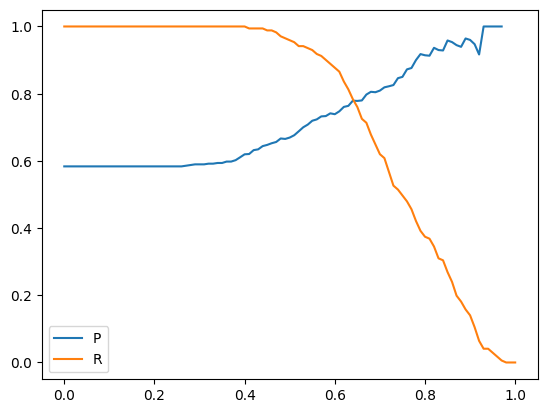

In [76]:
scores = []

thresholds = np.linspace(0, 1, 101)
for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)

plt.plot(df_scores.threshold, df_scores['precision'], label='P')
plt.plot(df_scores.threshold, df_scores['recall'], label='R')
plt.legend()

In [77]:
df_scores.iloc[65]

threshold      0.650000
tp           130.000000
fp            37.000000
fn            41.000000
tn            85.000000
precision      0.778443
recall         0.760234
Name: 65, dtype: float64

## Question 4: F1 score
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

F1 = 2PR/(P+R)
where P is precision and R is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal? c. 0.54, actual is 0.56 but no option

In [78]:
df_scores['f1'] = 2 * df_scores.precision * df_scores.recall / (df_scores.precision + df_scores.recall)

In [79]:
max_index = df_scores['f1'].idxmax()
max_index
# so max is 0.56

57

## Question 5: 5-Fold CV
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1)

1. Iterate over different folds of df_full_train
2. Split the data into train and validation
3. Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
4. Use AUC to evaluate the model on validation
5. How large is standard deviation of the scores across different folds? c. 0.06, actual 0.036 but no option

In [80]:
from sklearn.model_selection import KFold

In [83]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values


    dv = DictVectorizer(sparse=False)

    train_dict = df_train[categorical + numerical].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)
    
    val_dict = df_val[categorical + numerical].to_dict(orient='records')
    X_val = dv.transform(val_dict)
    
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)
print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.822 +- 0.036


## Question 6: Hyperparameter Tuning
Now let's use 5-Fold cross-validation to find the best parameter C

Iterate over the following C values: [0.000001, 0.001, 1]
Initialize KFold with the same parameters as previously

Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)

Compute the mean score as well as the std (round the mean and std to 3 decimal digits)
Which C leads to the best mean score?

If you have ties, select the score with the lowest std. If you still have ties, select the smallest C.

In [85]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []
C = [0.000001, 0.001, 1]

for c in C:
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
    
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
    
        dv = DictVectorizer(sparse=False)
    
        train_dict = df_train[categorical + numerical].to_dict(orient='records')
        X_train = dv.fit_transform(train_dict)
        
        val_dict = df_val[categorical + numerical].to_dict(orient='records')
        X_val = dv.transform(val_dict)
        
        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:, 1]
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    print('C = %f, %.3f +- %.3f' % (c, np.mean(scores), np.std(scores)))

C = 0.000001, 0.560 +- 0.024
C = 0.001000, 0.714 +- 0.156
C = 1.000000, 0.750 +- 0.139
